In [18]:
import sys, pathlib
CWD = pathlib.Path.cwd().resolve()
ROOT = CWD if (CWD / 'src').exists() else CWD.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

IMAGE_PATH    = ROOT / 'data' / 'sample_image.jpg'
MEASURES_PATH = ROOT / 'data' / 'sample_measures.json'
HORIZON_CACHE = ROOT / 'data' / 'horizon_profile.json'

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.SolarModel import SolarModel
from src.names import SolarModelOptions, PyranoInfo, PyranoMeasure, RealPyrano, VirtualPyrano
from src.vision import compute_horizon_from_image, SINGLE_HALF_RIGHT
from src.values import KD_GRID_MIN, KD_GRID_MAX, KD_GRID_STEPS
from src.solver import F1_MIN, F1_MAX, F2_MIN, F2_MAX

print('Imports OK')
print(f'Bornes 3D : kd [0,1]  f1 [{F1_MIN},{F1_MAX}]  f2 [{F2_MIN},{F2_MAX}]')


Imports OK
Bornes 3D : kd [0,1]  f1 [0.0,1]  f2 [-1.8,0.5]


In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.SolarModel import SolarModel
from src.names import (
    SolarModelOptions,
    PyranoInfo, PyranoMeasure,
    RealPyrano, VirtualPyrano,
)
from src.vision import compute_horizon_from_image, SINGLE_HALF_RIGHT
from src.values import KD_GRID_MIN, KD_GRID_MAX, KD_GRID_STEPS

print('Imports OK')

Imports OK


## 1. Extraction du profil d'horizon depuis l'image fisheye

Si `01_test_vision.ipynb` a déjà été exécuté, le cache `horizon_profile.json`
est utilisé directement pour eviter de recharger MiDaS. Sinon, le pipeline
vision complet est lance ici (environ 30s au premier appel).

Horizons chargés depuis le cache (Toit et Façade).


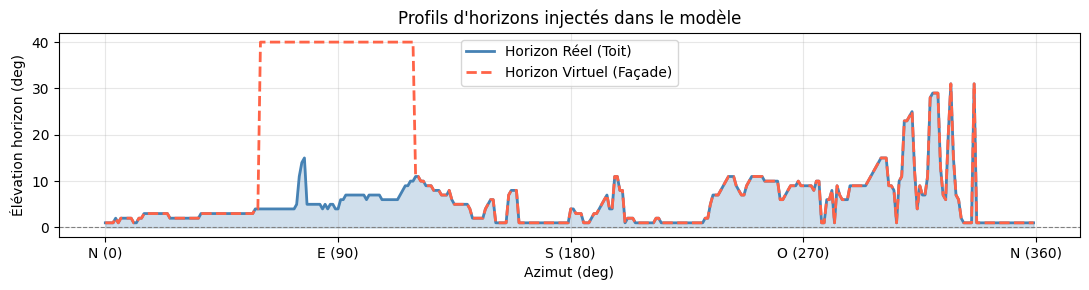

In [20]:
if HORIZON_CACHE.exists():
    with open(HORIZON_CACHE) as f:
        horizon_data = json.load(f)
    # Chargement dynamique des deux profils
    horizon_real = np.array(horizon_data.get('horizon_real', np.zeros(360)))
    horizon_virtual = np.array(horizon_data.get('horizon_virtual_1', np.zeros(360)))
    print(f"Horizons chargés depuis le cache (Toit et Façade).")
elif IMAGE_PATH.exists():
    print("Calcul du profil d'horizon via MiDaS...")
    horizon_real = compute_horizon_from_image(
        image_path = str(IMAGE_PATH), fov_deg = 180, single_half = SINGLE_HALF_RIGHT,
        azimuth_deg = 0.0, inclination_deg = 0.0
    )
    horizon_virtual = horizon_real.copy() # Par défaut, on met le même
    with open(HORIZON_CACHE, 'w') as f:
        json.dump({'horizon_real': horizon_real.tolist(), 'horizon_virtual_1': horizon_virtual.tolist()}, f)
else:
    print("ATTENTION : utilisation d'un horizon plat.")
    horizon_real = np.zeros(360)
    horizon_virtual = np.zeros(360)

# --- Affichage comparatif ---
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(np.arange(360), np.rad2deg(horizon_real), color='steelblue', linewidth=2, label='Horizon Réel (Toit)')
ax.plot(np.arange(360), np.rad2deg(horizon_virtual), color='tomato', linestyle='--', linewidth=2, label='Horizon Virtuel (Façade)')
ax.fill_between(np.arange(360), np.rad2deg(horizon_real), alpha=0.25, color='steelblue')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Azimut (deg)')
ax.set_ylabel('Élévation horizon (deg)')
ax.set_title("Profils d'horizons injectés dans le modèle")
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N (0)', 'E (90)', 'S (180)', 'O (270)', 'N (360)'])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Chargement des mesures

In [21]:
with open(MEASURES_PATH) as f:
    raw = json.load(f)

meta         = raw['meta']
measurements = raw['measurements']

# Extraction des données communes
timestamps   = np.array([m['time'] for m in measurements])
origin_vals  = np.array([m['pyrano_origin_wm2'] for m in measurements], dtype=float)
dest_configs = measurements[0]['pyrano_dest']

print(f"Site      : {meta['site']}")
print(f"Periode   : {timestamps[0]}  ->  {timestamps[-1]}")
print(f"GHI range : {origin_vals.min():.1f} - {origin_vals.max():.1f} W/m²")



Site      : Paris, toit Haussmannien
Periode   : 2024-06-21 07:00:00.000  ->  2024-06-21 16:00:00.000
GHI range : 150.0 - 900.0 W/m²


## 3. Pipeline 1D — fit_parameters() par instant

Boucle sur chaque instant de mesure : un `SolarModel` est créé, ses pyranomètres
enregistrés, puis `fit_parameters()` calibre **kd** uniquement (Grid Search 1D).
f1 et f2 restent calculés par les **tables de Perez** lors de la projection.


In [31]:
# Options globales (identiques pour toutes les mesures)
options = SolarModelOptions(
    latitude        = meta['latitude'],
    longitude       = meta['longitude'],
    elevation_meter = meta['elevation_meter'],
    albedo          = 0.2,
    use_riso        = True,
)

print(f"Site : {meta['site']}")
print(f"Simulation 1D de {len(measurements)} instants de mesure...\n")

results_list = []
kd_history   = []
time_history = []
models_cache = []   # conservés pour la boucle 3D (settings déjà construits)

for m in measurements:
    t_str = m['time']
    time_history.append(t_str.split(' ')[1][:5])

    model = SolarModel(options)

    model.set_origin(RealPyrano(
        info     = PyranoInfo(azimuth_deg=0.0, inclination_deg=0.0, horizon=horizon_real),
        measures = PyranoMeasure(
            timestamps = np.array([t_str]),
            values     = np.array([m['pyrano_origin_wm2']], dtype=float)
        )
    ))

    for fit in m['pyrano_fit']:
        model.add_fit(RealPyrano(
            info     = PyranoInfo(
                azimuth_deg     = float(fit['azimuth_deg']),
                inclination_deg = float(fit['inclination_deg']),
                horizon         = horizon_real
            ),
            measures = PyranoMeasure(
                timestamps = np.array([t_str]),
                values     = np.array([fit['value_wm2']], dtype=float)
            )
        ))

    for dest in m['pyrano_dest']:
        model.add_target(VirtualPyrano(
            info=PyranoInfo(
                azimuth_deg     = float(dest['azimuth_deg']),
                inclination_deg = float(dest['inclination_deg']),
                horizon         = horizon_virtual
            )
        ))

    # ── Pipeline 1D ──────────────────────────────────────────────────────────
    model.fit_parameters()            # calibre kd (Grid Search)
    kd_history.append(model.kd)      # model.kd = résultat du pipeline 1D

    df_instant = model.project()      # f1/f2 recalculés par Perez
    results_list.append(df_instant)
    models_cache.append(model)        # gardé pour la boucle 3D

df_final = pd.concat(results_list, ignore_index=True)
print(f"\nPipeline 1D terminé — kd moyen : {np.mean(kd_history):.3f}")


Site : Paris, toit Haussmannien
Simulation 1D de 10 instants de mesure...

[solver] kd optimal : 0.5253  (index médian : 52)
[solver] kd optimal : 0.4647  (index médian : 46)
[solver] kd optimal : 0.4546  (index médian : 45)
[solver] kd optimal : 0.6667  (index médian : 66)
[solver] kd optimal : 0.0001  (index médian : 0)
[solver] kd optimal : 0.0001  (index médian : 0)
[solver] kd optimal : 0.1112  (index médian : 11)
[solver] kd optimal : 0.6667  (index médian : 66)
[solver] kd optimal : 0.5051  (index médian : 50)
[solver] kd optimal : 0.8081  (index médian : 80)

Pipeline 1D terminé — kd moyen : 0.420


## 4. Évolution du kd (Pipeline 1D)


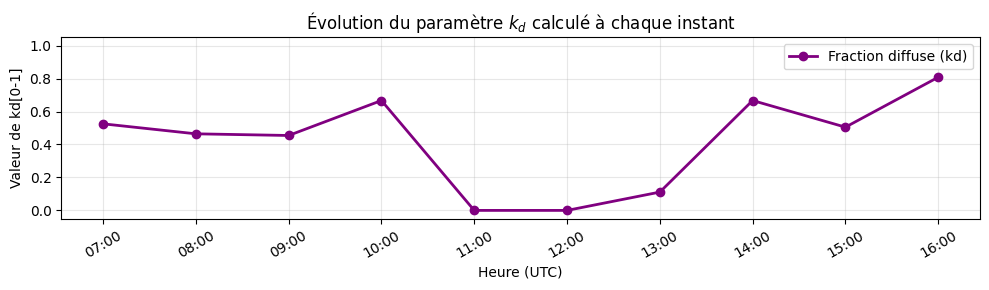

Moyenne kd sur la période : 0.420


In [33]:
x = np.arange(len(time_history))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x, kd_history, marker='o', color='purple', linewidth=2, label='Fraction diffuse (kd)')
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)')
ax.set_ylabel('Valeur de kd[0-1]')
ax.set_title('Évolution du paramètre $k_d$ calculé à chaque instant')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne kd sur la période : {np.mean(kd_history):.3f}")

## 5. Pipeline 3D — fit_parameters_3d() par instant

Le solveur 3D optimise **kd, f1 et f2 simultanément** (L-BFGS-B, multi-start).

$$\min_{k_d, f_1, f_2} \sum_{i=1}^{N_{fits}} \left| GTI_{sim,i}(k_d, f_1, f_2) - GTI_{real,i} \right|$$

**Contraintes physiques :**
| Paramètre | Borne inf | Borne sup | Signification |
|-----------|-----------|-----------|---------------|
| `kd`      | 0.0       | 1.0       | fraction diffuse |
| `f1`      | 0.0       | 1.5       | brightening circumsolaire ≥ 0 |
| `f2`      | -1.8      | 0.5       | brightening d'horizon (peut être négatif) |

`model.kd` (résultat 1D) est passé comme point de départ pour accélérer la convergence.


In [24]:
# ── Pipeline 3D : réutilise les modèles déjà construits par la boucle 1D ─────
print(f"Simulation 3D de {len(measurements)} instants...\n")

kd_3d_history  = []
f1_3d_history  = []
f2_3d_history  = []
err_3d_history = []
results_3d_list = []

for model in models_cache:
    # _settings, _gamma_s, _alpha_s, _TOANI sont déjà calculés par fit_parameters()
    # fit_parameters_3d() les détecte et les réutilise directement
    # model.kd (pipeline 1D) est passé automatiquement comme point de départ
    model.fit_parameters_3d(n_restarts=6)

    kd_3d_history.append(model.kd_3d)
    f1_3d_history.append(model.f1_3d)
    f2_3d_history.append(model.f2_3d)
    err_3d_history.append(model.error_3d)

    df_3d = model.project_3d()
    results_3d_list.append(df_3d)

df_final_3d = pd.concat(results_3d_list, ignore_index=True)
print(f"\nPipeline 3D terminé — kd moyen : {np.mean(kd_3d_history):.3f}")
print(f"  f1 moyen : {np.mean(f1_3d_history):.3f}   f2 moyen : {np.mean(f2_3d_history):.3f}")


Simulation 3D de 10 instants...

[solver 3D] kd=0.6302  f1=0.4201  f2=0.0169  err=20.96 W/m²  (restarts=6)
[solver 3D] kd=0.3846  f1=0.3608  f2=0.1970  err=54.50 W/m²  (restarts=6)
[solver 3D] kd=0.4659  f1=0.4888  f2=0.0778  err=36.75 W/m²  (restarts=6)
[solver 3D] kd=0.6970  f1=0.4322  f2=-0.1858  err=50.70 W/m²  (restarts=6)
[solver 3D] kd=0.2565  f1=0.6159  f2=-0.3892  err=70.62 W/m²  (restarts=6)
[solver 3D] kd=0.2488  f1=0.6935  f2=-0.4552  err=47.80 W/m²  (restarts=6)
[solver 3D] kd=0.5155  f1=0.5814  f2=-0.1532  err=130.44 W/m²  (restarts=6)
[solver 3D] kd=0.5870  f1=0.2740  f2=-0.2353  err=58.23 W/m²  (restarts=6)
[solver 3D] kd=0.3520  f1=0.2423  f2=-0.1045  err=16.57 W/m²  (restarts=6)
[solver 3D] kd=0.4299  f1=0.0067  f2=-0.4291  err=9.07 W/m²  (restarts=6)

Pipeline 3D terminé — kd moyen : 0.457
  f1 moyen : 0.412   f2 moyen : -0.166


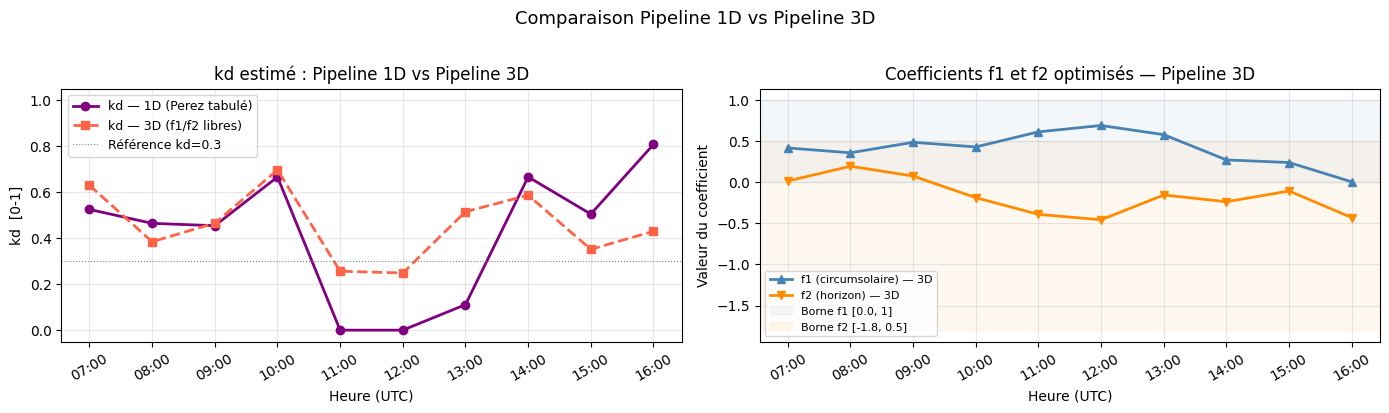

In [34]:
# ── Comparaison kd_1D vs kd_3D  +  évolution f1 / f2 ────────────────────────
x = np.arange(len(time_history))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(x, kd_history,    marker='o', color='purple', lw=2,
        label='kd — 1D (Perez tabulé)')
ax.plot(x, kd_3d_history, marker='s', color='tomato', lw=2, linestyle='--',
        label='kd — 3D (f1/f2 libres)')
ax.axhline(0.3, color='gray', linestyle=':', lw=0.8, label='Référence kd=0.3')
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)'); ax.set_ylabel('kd  [0-1]')
ax.set_title('kd estimé : Pipeline 1D vs Pipeline 3D')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, f1_3d_history, marker='^', color='steelblue',  lw=2, label='f1 (circumsolaire) — 3D')
ax.plot(x, f2_3d_history, marker='v', color='darkorange', lw=2, label='f2 (horizon) — 3D')
ax.axhspan(F1_MIN, F1_MAX, alpha=0.06, color='steelblue',
           label=f'Borne f1 [{F1_MIN}, {F1_MAX}]')
ax.axhspan(F2_MIN, F2_MAX, alpha=0.06, color='darkorange',
           label=f'Borne f2 [{F2_MIN}, {F2_MAX}]')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)'); ax.set_ylabel('Valeur du coefficient')
ax.set_title('Coefficients f1 et f2 optimisés — Pipeline 3D')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison Pipeline 1D vs Pipeline 3D', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


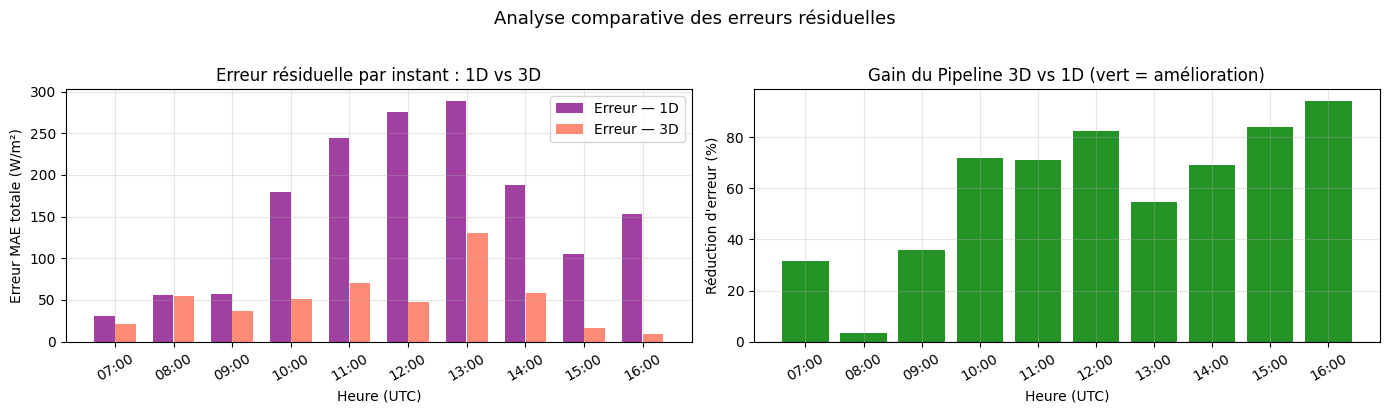

Erreur 1D  moyenne : 157.82 W/m²
Erreur 3D  moyenne : 49.56 W/m²
Gain moyen         : 59.9%


In [35]:
# ── Erreurs résiduelles : 1D vs 3D ──────────────────────────────────────────
# model.errors shape = (T, n_kd) ; T=1 ici (un instant par modèle)
# model.optimal_index[0] = index du kd optimal pour cet instant
err_1d_history = []
for model in models_cache:
    kd_idx = model.optimal_index[0]
    err_1d_history.append(float(model.errors[0, kd_idx]))

x = np.arange(len(time_history))
gain = [(e1 - e3) / max(e1, 1e-3) * 100
        for e1, e3 in zip(err_1d_history, err_3d_history)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(x - 0.18, err_1d_history, width=0.35, color='purple', alpha=0.75, label='Erreur — 1D')
ax.bar(x + 0.18, err_3d_history, width=0.35, color='tomato',  alpha=0.75, label='Erreur — 3D')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)'); ax.set_ylabel('Erreur MAE totale (W/m²)')
ax.set_title('Erreur résiduelle par instant : 1D vs 3D')
ax.legend(); ax.grid(True, alpha=0.3)

colors_bar = ['green' if g >= 0 else 'red' for g in gain]
ax = axes[1]
ax.bar(x, gain, color=colors_bar, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)'); ax.set_ylabel("Réduction d'erreur (%)")
ax.set_title("Gain du Pipeline 3D vs 1D (vert = amélioration)")
ax.grid(True, alpha=0.3)

plt.suptitle("Analyse comparative des erreurs résiduelles", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"Erreur 1D  moyenne : {np.mean(err_1d_history):.2f} W/m²")
print(f"Erreur 3D  moyenne : {np.mean(err_3d_history):.2f} W/m²")
print(f"Gain moyen         : {np.mean(gain):.1f}%")


In [36]:
# ── Tableau récapitulatif des deux pipelines ─────────────────────────────────
df_compare = pd.DataFrame({
    'Heure'   : time_history,
    'kd_1D'   : [round(v, 4) for v in kd_history],
    'kd_3D'   : [round(v, 4) for v in kd_3d_history],
    'Delta_kd': [round(v3 - v1, 4) for v1, v3 in zip(kd_history, kd_3d_history)],
    'f1_3D'   : [round(v, 4) for v in f1_3d_history],
    'f2_3D'   : [round(v, 4) for v in f2_3d_history],
    'Err_1D'  : [round(v, 2) for v in err_1d_history],
    'Err_3D'  : [round(v, 2) for v in err_3d_history],
    'Gain_%'  : [round(g, 1) for g in gain],
})

print("\n═══ Comparaison Pipeline 1D vs Pipeline 3D ═══")
display(df_compare)

OUTPUT_COMP = ROOT / 'data' / 'results_comparison.csv'
df_compare.to_csv(OUTPUT_COMP, index=False)
print(f"\nExporté : {OUTPUT_COMP}")
print()
print("Interprétation :")
print("  |Δkd| < 0.05  → le ciel correspond bien aux tables de Perez")
print("  |Δkd| > 0.10  → conditions atmosphériques atypiques ce jour-là")
print("  Gain > 30%    → f1/f2 libres apportent un gain significatif de précision")



═══ Comparaison Pipeline 1D vs Pipeline 3D ═══


,Heure,kd_1D,kd_3D,Delta_kd,f1_3D,f2_3D,Err_1D,Err_3D,Gain_%
0,07:00,0.5253,0.6302,0.1049,0.4201,0.0169,30.61,20.96,31.5
1,08:00,0.4647,0.3846,-0.0801,0.3608,0.1970,56.44,54.50,3.4
2,09:00,0.4546,0.4659,0.0113,0.4888,0.0778,57.32,36.75,35.9
3,10:00,0.6667,0.6970,0.0303,0.4322,-0.1858,180.00,50.70,71.8
4,11:00,0.0001,0.2565,0.2564,0.6159,-0.3892,244.59,70.62,71.1
5,12:00,0.0001,0.2488,0.2487,0.6935,-0.4552,275.14,47.80,82.6
6,13:00,0.1112,0.5155,0.4043,0.5814,-0.1532,288.36,130.44,54.8
7,14:00,0.6667,0.5870,-0.0797,0.2740,-0.2353,188.32,58.23,69.1
8,15:00,0.5051,0.3520,-0.1531,0.2423,-0.1045,104.78,16.57,84.2
9,16:00,0.8081,0.4299,-0.3782,0.0067,-0.4291,152.68,9.07,94.1



Exporté : C:\Users\OMAR\Desktop\Solar\data\results_comparison.csv

Interprétation :
  |Δkd| < 0.05  → le ciel correspond bien aux tables de Perez
  |Δkd| > 0.10  → conditions atmosphériques atypiques ce jour-là
  Gain > 30%    → f1/f2 libres apportent un gain significatif de précision


## 6. Projection GTI sur les façades — Comparaison 1D vs 3D


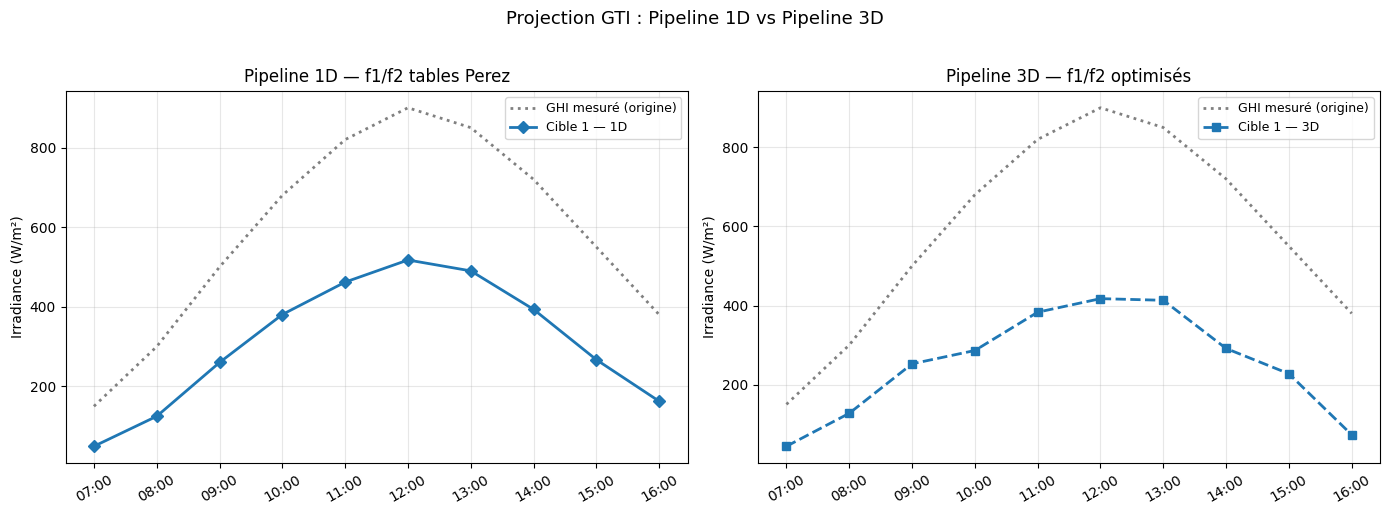

In [37]:
# ── GTI projeté sur les façades : 1D vs 3D ───────────────────────────────────
origin_vals  = df_final['pyrano-origin'].values
dest_cols_1d = [c for c in df_final.columns    if 'dest' in c and 'value' in c]
dest_cols_3d = [c for c in df_final_3d.columns if 'dest' in c and 'value' in c]
x = np.arange(len(time_history))
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x, origin_vals, color='gray', linestyle=':', lw=2, label='GHI mesuré (origine)')
for i, col in enumerate(dest_cols_1d):
    ax.plot(x, df_final[col].values, marker='D', color=colors[i], lw=2,
            label=f'Cible {i+1} — 1D')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_ylabel('Irradiance (W/m²)')
ax.set_title('Pipeline 1D — f1/f2 tables Perez')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, origin_vals, color='gray', linestyle=':', lw=2, label='GHI mesuré (origine)')
for i, col in enumerate(dest_cols_3d):
    ax.plot(x, df_final_3d[col].values, marker='s', color=colors[i], lw=2,
            linestyle='--', label=f'Cible {i+1} — 3D')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_ylabel('Irradiance (W/m²)')
ax.set_title('Pipeline 3D — f1/f2 optimisés')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Projection GTI : Pipeline 1D vs Pipeline 3D', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


In [38]:
# Export
OUTPUT = ROOT / 'data' / 'results_dynamic.csv'
df_final.to_csv(OUTPUT, index=False)
print(f'Résultats exportés : {OUTPUT}')

Résultats exportés : C:\Users\OMAR\Desktop\Solar\data\results_dynamic.csv


In [39]:
# 1. On ajoute la liste des kd calculés directement dans le DataFrame final
df_final['kd_optimal'] = kd_history

# 2. Préparation des colonnes de base
cols_show =['time', 'kd_optimal', 'pyrano-origin']
rename_dict = {
    'time': 'Heure (UTC)', 
    'kd_optimal': 'Fraction Diffuse (kd)',
    'pyrano-origin': 'GHI Mesuré (W/m²)'
}

# 3. Ajout dynamique des colonnes de Fit (Sud, Est, Ouest...)
nb_fits = len(measurements[0]['pyrano_fit'])
for i in range(nb_fits):
    col_name = f'pyrano-fit-{i+1}_value'
    az  = measurements[0]['pyrano_fit'][i]['azimuth_deg']
    inc = measurements[0]['pyrano_fit'][i]['inclination_deg']
    
    cols_show.append(col_name)
    rename_dict[col_name] = f'GTI Fit {i+1} (Az={az:.0f}°, Inc={inc:.0f}°)'

# 4. Ajout dynamique des colonnes de Destination (Les façades cibles)
nb_dests = len(measurements[0]['pyrano_dest'])
for i in range(nb_dests):
    col_name = f'pyrano-dest-{i+1}_value'
    az  = measurements[0]['pyrano_dest'][i]['azimuth_deg']
    inc = measurements[0]['pyrano_dest'][i]['inclination_deg']
    
    cols_show.append(col_name)
    rename_dict[col_name] = f'GTI Cible {i+1} (Az={az:.0f}°, Inc={inc:.0f}°)'

# 5. Affichage du magnifique tableau propre
print("📊 Tableau récapitulatif des projections par instant :")
display(df_final[cols_show].rename(columns=rename_dict).round(3))

📊 Tableau récapitulatif des projections par instant :


,Heure (UTC),Fraction Diffuse (kd),GHI Mesuré (W/m²),"GTI Fit 1 (Az=180°, Inc=45°)","GTI Fit 2 (Az=90°, Inc=60°)","GTI Fit 3 (Az=270°, Inc=60°)","GTI Cible 1 (Az=180°, Inc=90°)"
0,2024-06-21 07:00:00.000,0.525,150.0,90.0,250.0,50.0,49.508
1,2024-06-21 08:00:00.000,0.465,300.0,220.0,450.0,90.0,124.941
2,2024-06-21 09:00:00.000,0.455,500.0,450.0,600.0,130.0,260.085
3,2024-06-21 10:00:00.000,0.667,680.0,650.0,550.0,180.0,380.591
4,2024-06-21 11:00:00.000,0.000,820.0,800.0,480.0,250.0,461.989
5,2024-06-21 12:00:00.000,0.000,900.0,880.0,400.0,400.0,517.554
6,2024-06-21 13:00:00.000,0.111,850.0,820.0,280.0,500.0,490.177
7,2024-06-21 14:00:00.000,0.667,720.0,680.0,180.0,600.0,393.425
8,2024-06-21 15:00:00.000,0.505,550.0,480.0,120.0,650.0,266.943
9,2024-06-21 16:00:00.000,0.808,380.0,280.0,80.0,450.0,162.535
